# Gene level evaluation

In this notebook we focus on how to train InterScale using the molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w) which we preprocessed in the [previous tutorial](./1_model_training.ipynb). 

**Requirements**:

- inference results in the anndata object OR
- trained model to load inference results

## Import packages

In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

/usr/local/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/usr/local/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/usr/local/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/usr/local/lib/python3.13/site-packages/spatial

In [2]:
import interscale
from interscale.config import load_config
from interscale.evaluation import gene_loadings, gene_rank_analysis
from interscale.tl import set_full_reproducibility

ModuleNotFoundError: No module named 'interscale.evaluation.clustering'

In [ ]:
set_full_reproducibility()

In [ ]:
import sys

# Find repo root by locating paths.py
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "legnini"

In [ ]:
# %%
import yaml
from pathlib import Path
import warnings

# %%
warnings.filterwarnings("ignore")


# %%


# %%
class Plotting:
    """
    Class to create atlas figures with config yml
    """

    def __init__(self, config_path, output_dir="figures"):
        self.config = self._load_config(config_path)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self._setup_plotting_params()

    def _load_config(self, config_path):
        """Load configuration from YAML file"""
        if isinstance(config_path, str):
            with open(config_path) as f:
                return yaml.safe_load(f)
        elif isinstance(config_path, dict):
            return config_path
        else:
            raise ValueError("Config must be a file path or dictionary")

    def _setup_plotting_params(self):
        """Set up matplotlib and scanpy plotting parameters"""
        cfg = self.config["plot_configs"]["general"]
        plt.rcParams["figure.dpi"] = cfg["dpi"]
        plt.rcParams["savefig.dpi"] = cfg["dpi_save"]
        plt.rcParams["legend.fontsize"] = cfg["legend_fontsize"]
        plt.rcParams["axes.titlesize"] = cfg["title_fontsize"]
        plt.rcParams["font.family"] = cfg["font_family"]
        cmap_cfg = cfg.get("cmap", "viridis")
        if isinstance(cmap_cfg, str):
            cm = plt.get_cmap(cmap_cfg)
            # Sample a categorical cycle from the continuous cmap
            palette = [cm(x) for x in np.linspace(0.1, 0.9, 10)]
        elif isinstance(cmap_cfg, (list, tuple)):
            palette = list(cmap_cfg)
            cmap_name = "viridis"  # Default fallback for image.cmap
        else:
            raise ValueError("plot_configs.general.cmap must be a colormap name, not a list or tuple")
        plt.rcParams["axes.prop_cycle"] = plt.cycler(color=palette)
        plt.rcParams["image.cmap"] = cmap_name
        sns.set_theme(style="white", font=cfg["font_family"])
        sc.settings.set_figure_params(dpi_save=cfg["dpi_save"], fontsize=cfg["legend_fontsize"])


plotting = Plotting(config_path)
plotting._setup_plotting_params()

## Parameter setting

In [ ]:
# legnini23: #to change
#     Immune Cell: "#4363d8"
#     Epithelial Cell: "#e6194B"
#     Stromal Cell: "#25e907"
#     ring_1: "#EE9B00" # furthest from SHH source
#     ring_2: "#AE2012"
#     ring_3: "#88C8B2"
#     ring_4: "#005F73" # closest to SHH source
CONDITION_COLORS = {"Ctrl": "#005F73", "SHH": "#EE9B00"}

## Load data, config and model

First we load the preprocessed data from the [previous tutorial](./1_model_training.ipynb).

In [ ]:
result = sc.read_h5ad(f"{BASE_DIR_PROJECT}/data/{DATA}_trained.h5ad")

In [ ]:
result

In [ ]:
cfg = load_config(Path(f"{BASE_DIR_PROJECT}/config_files/{DATA}_example.yaml"))

In [ ]:
cfg

In [ ]:
model_path = f"{DATA}/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model.ckpt"

## Gene rank analysis 

First we check whether the local and global embeddings capture different genes using the `gene_rank_analysis()`

Top 5 genes for _y_pred_local model:
      gene        r2    r2_log  r2_rank
26  FOXA2 -0.005921 -0.005938     88.0
48   MNX1 -0.007221 -0.007247     87.0
74    SHH -0.011011 -0.011072     86.0
36   HEY1 -0.020272 -0.020481     85.0
62  OLIG2 -0.022693 -0.022955     84.0
Top 5 genes for _y_pred_global model:
      gene        r2    r2_log  r2_rank
43   JUNB  0.016829  0.016689     88.0
64   OTX2 -0.000101 -0.000101     87.0
26  FOXA2 -0.000727 -0.000727     86.0
25  FOXA1 -0.004611 -0.004622     85.0
61  OLIG1 -0.005234 -0.005248     84.0


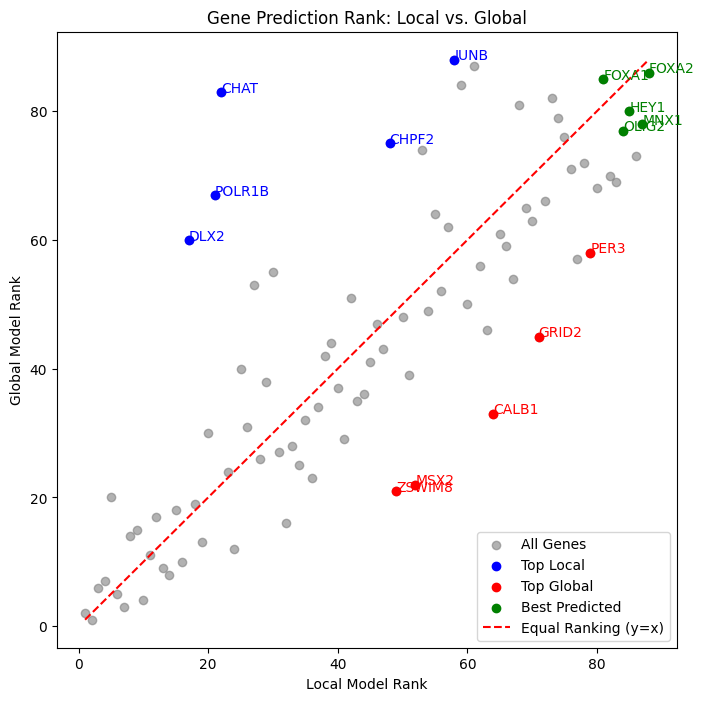

In [12]:
gene_rank_analysis(result, layers_local_pred="_y_pred_local", layers_global_pred="_y_pred_global", plot_result=True)

## Gene loadings

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (graph), (2) node label (node) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys:

- `prediction_obs`: Label in adata.obs to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from adata.layer
- `sample_key`: adata.obs used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a adata.obs group that we want to stratify during sampling

In [ ]:
interscale.model.CombinedModel._setup_anndata(
    adata=adata, prediction_task="regression", layer_key="log1p_norm", sample_key_list=["sample"], split_key="split"
)

Anndata setup with scvi-tools version 1.4.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_sample_key_0  │  17   │
│   n_split_key    │   3   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│  split_key   │  adata.obs['_scvi_split_key']   │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                split_key State Registry                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['split'] │    test    │          0          │
│                    │   train    │          1          │
│                    │    val     │          2          │
└────────────────────┴────────────┴─────────────────────┘

When run interactively, then check whether the the variables used to set up the anndata are the same as in the config.

In [10]:
model = interscale.model.CombinedModel(adata, cfg=cfg)

In [11]:
print(model._model_summary_string)

regression model for node prediction. 
Dual Decoder Combined Module: 
Local Module: GCN Local Component: 
n_layers: 2, 
n_hidden: 256, 
n_embed: 16, 
dropout_local: 0.1
Global Module: Transformer Encoder Global Component: 
max_seq_len: 4299, 
n_heads: 4, 
act_func: relu, 
num_layers: 2, 




In [ ]:
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(
    datas=pyg_data_list,
    num_workers=1,
    batch_size=int(cfg.dataset.batch_size),
    pct_mask_nodes=cfg.dataset.pct_mask_nodes,
    learning_type="node",
)

Split key split already exists in adata.obs


In [ ]:
model.train(max_epochs=20, datamodule=dm, early_stopping=True, wandb_use=False)

[rank: 0] Seed set to 44
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Steps per epoch 4
cross-cell per gene correlation metrics


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ module        │ DualDecoderCombinedModule │ 51.2 K │ train │     0 │
│ 1 │ loss          │ SmoothL1Loss              │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection          │      0 │ train │     0 │
│ 3 │ valid_metrics │ MetricCollection          │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection          │      0 │ train │     0 │
└───┴───────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 51.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 63                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


...

Output()

on_test_epoch_end 20

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │            nan            │
│     test_global_loss      │    1.6581462621688843     │
│      test_local_loss      │    1.6778740882873535     │
│         test_loss         │    1.6680102348327637     │
│         test_mse          │     8.528382301330566     │
│     test_pearson_corr     │   0.025037476792931557    │
│          test_r2          │    -5.0938873291015625    │
└───────────────────────────┴───────────────────────────┘

`weights_only` was not set, defaulting to `False`.


Model checkpoint will be saved in:  /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model.ckpt


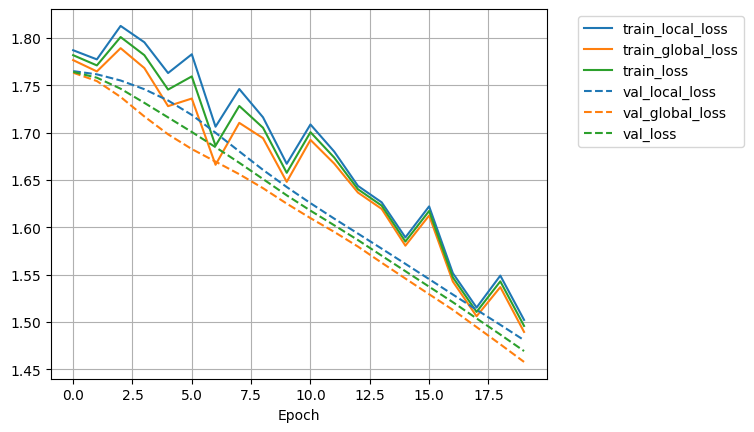

In [15]:
model.history_.plot_history(subset_term="loss")

In [16]:
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


In [17]:
result.write(f"{BASE_DIR_PROJECT}/data/{DATA}_trained.h5ad")

In [29]:
gene_loadings(
    result,
    dual_combined_model,
    local_latent_key="_global_emb",
    global_latent_key="_global_emb",
    layer_key="log1p_norm",
)

NameError: name 'dual_combined_model' is not defined